# San Diego Parking Stay-Duration Classification (Long Stay vs Short Stay)
**Source:** City of San Diego Open Data Portal  
**Dataset 1:** Parking Meter Transactions 2020 — 1,953,052 rows  
**Dataset 2:** Parking Meter Locations Active — 4,060 rows  
**Task:** Classify whether a parking transaction will be a Long Stay (>60 mins) or Short Stay (<=60 mins)  
**Models:** Random Forest, XGBoost, CatBoost, MLP (neural network)

---

## Problem Statement
Drivers waste time searching for available parking in San Diego. This project does **not** predict real-time slot availability directly — that would require live occupancy sensor data, which is not present in this dataset. Instead, it predicts **stay-duration class**: whether a given parking transaction will be a Long Stay (>60 minutes) or a Short Stay (<=60 minutes), based on historical smart-meter transaction data.

Stay duration is a useful proxy for availability and turnover: zones dominated by Long Stay transactions have slower turnover (fewer slots freeing up), while Short Stay zones have faster turnover. The model's outputs can therefore support city planners and drivers in understanding *where and when* parking is likely to free up.

---

#  PREPROCESSING


---

# Load and Explore Raw Data
---

##  Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_score,
    recall_score, f1_score
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

print('All libraries loaded successfully.')

All libraries loaded successfully.


##  Load Datasets

In [18]:
# Load Parking Meter Locations (Active)
locations = pd.read_csv('parking_meters_current.csv')

print(f'Locations loaded.')
print(f'Rows    : {locations.shape[0]:,}')
print(f'Columns : {locations.shape[1]}')
locations.head()

Locations loaded.
Rows    : 4,060
Columns : 16


,zone,area,sub-area,pole,latitude,longitude,configid,configname,time_start,time_end,time_limit,days_in_operation,price,mobile_pay,multi_space,restrictions
0,Spares,Spares,Spares,Spares (San Diego CA),32.715329,-117.157255,63,San Diego Default,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Downtown,Core - Columbia,1000 SECOND AVE,2-1014,32.716327,-117.162596,57001,"Downtown MK5 – 30 Min Max $2.50 HR, 8am-8pm, M...",8am,8pm,30 min,Mon-Sat,$2.50 HR,NaN,NaN,NaN
2,Downtown,Core - Columbia,1000 SECOND AVE,2-1016,32.716370,-117.162933,57001,"Downtown MK5 – 30 Min Max $2.50 HR, 8am-8pm, M...",8am,8pm,30 min,Mon-Sat,$2.50 HR,NaN,NaN,NaN
3,Downtown,Core - Columbia,1000 SECOND AVE,2-1018,32.716393,-117.162453,57001,"Downtown MK5 – 30 Min Max $2.50 HR, 8am-8pm, M...",8am,8pm,30 min,Mon-Sat,$2.50 HR,NaN,NaN,NaN
4,Downtown,Core - Columbia,100 A ST,A-106,32.718846,-117.163056,57004,"Downtown MK5 - 2 Hour Max $2.50 HR, 8am-8pm, M...",8am,8pm,2 hour,Mon-Sat,$2.50 HR,NaN,NaN,NaN


In [19]:
# Load Parking Meter Transactions 2020
# Source: https://seshat.datasd.org/parking_meters_transactions/treas_parking_payments_2020_datasd.csv
transactions = pd.read_csv('treas_parking_payments_2020_datasd.csv')

print(f'Transactions loaded.')
print(f'Rows    : {transactions.shape[0]:,}')
print(f'Columns : {transactions.shape[1]}')
transactions.head()

Transactions loaded.
Rows    : 1,953,052
Columns : 6


,pole_id,meter_type,date_trans_start,date_meter_expire,trans_amt,pay_method
0,IV-424,SS,2020-02-24 11:39:31,2020-02-24 13:39:31,250,CREDIT CARD
1,IV-424,SS,2020-02-24 13:24:46,2020-02-24 15:24:46,225,CREDIT CARD
2,IV-424,SS,2020-02-24 15:25:52,2020-02-24 17:25:52,250,CREDIT CARD
3,NU-100,SS,2020-03-14 17:08:35,2020-03-14 17:56:35,100,CASH
4,NU-100,SS,2020-03-14 17:09:24,2020-03-14 18:00:00,25,CASH


##  Explore Locations

In [20]:
print('Columns:', list(locations.columns))
print('\nData types:')
print(locations.dtypes)
print('\nMissing values:')
print(locations.isnull().sum())

Columns: ['zone', 'area', 'sub-area', 'pole', 'latitude', 'longitude', 'configid', 'configname', 'time_start', 'time_end', 'time_limit', 'days_in_operation', 'price', 'mobile_pay', 'multi_space', 'restrictions']

Data types:
zone                  object
area                  object
sub-area              object
pole                  object
latitude             float64
longitude            float64
configid               int64
configname            object
time_start            object
time_end              object
time_limit            object
days_in_operation     object
price                 object
mobile_pay            object
multi_space           object
restrictions          object
dtype: object

Missing values:
zone                    0
area                    0
sub-area                0
pole                    0
latitude                0
longitude               0
configid                0
configname              0
time_start             42
time_end               42
time_limit          

In [21]:
print('Meters per zone:')
print(locations['zone'].value_counts())
print(f'\nUnique areas  : {locations["area"].nunique()}')
print(f'Unique meters : {locations["pole"].nunique()}')

Meters per zone:
zone
Downtown         2404
Uptown           1090
Mid-City          348
City               90
Balboa Park        60
Pacific Beach      29
San Ysidro         25
Test Zone          13
Spares              1
Name: count, dtype: int64

Unique areas  : 42
Unique meters : 4060


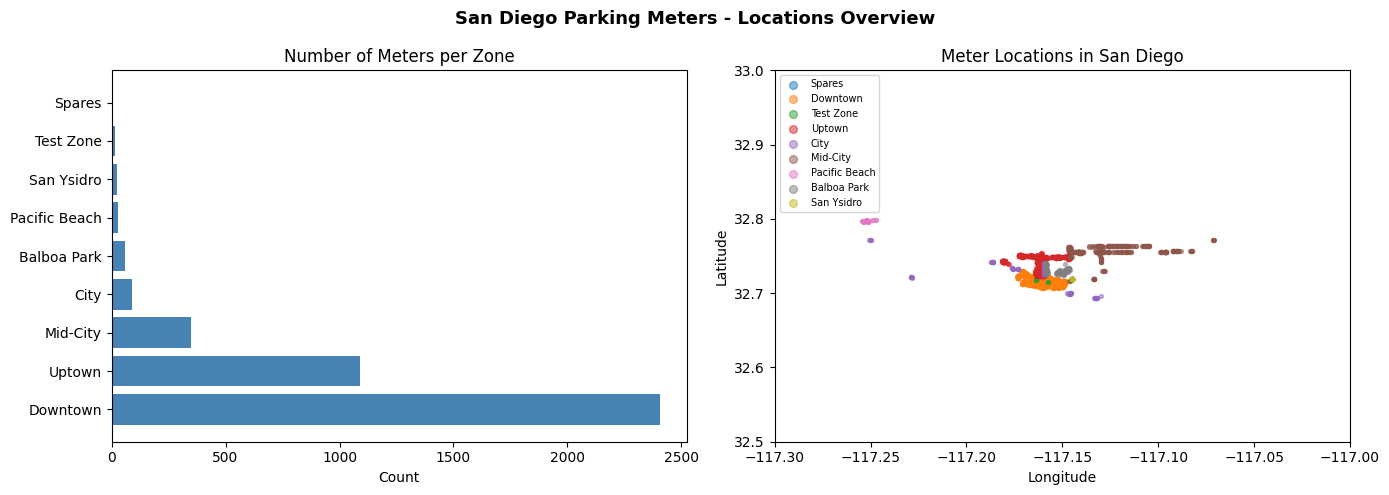

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('San Diego Parking Meters - Locations Overview', fontsize=13, fontweight='bold')

zone_counts = locations['zone'].value_counts()
axes[0].barh(zone_counts.index, zone_counts.values, color='steelblue')
axes[0].set_title('Number of Meters per Zone')
axes[0].set_xlabel('Count')

# Color by zone using a colormap
zones = locations['zone'].unique()
colors = plt.cm.tab10(range(len(zones)))
zone_color_map = dict(zip(zones, colors))

for zone in zones:
    subset = locations[locations['zone'] == zone]
    axes[1].scatter(subset['longitude'], subset['latitude'],
                    alpha=0.5, s=8, label=zone,
                    color=zone_color_map[zone])

axes[1].set_xlim(-117.3, -117.0)
axes[1].set_ylim(32.5, 33.0)
axes[1].set_title('Meter Locations in San Diego')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].legend(loc='upper left', fontsize=7, markerscale=2)

plt.tight_layout()
plt.show()

##  Explore Transactions

In [23]:
print('Columns:', list(transactions.columns))
print('\nData types:')
print(transactions.dtypes)
print('\nMissing values:')
print(transactions.isnull().sum())

Columns: ['pole_id', 'meter_type', 'date_trans_start', 'date_meter_expire', 'trans_amt', 'pay_method']

Data types:
pole_id              object
meter_type           object
date_trans_start     object
date_meter_expire    object
trans_amt             int64
pay_method           object
dtype: object

Missing values:
pole_id              0
meter_type           0
date_trans_start     0
date_meter_expire    0
trans_amt            0
pay_method           0
dtype: int64


In [24]:
transactions['date_trans_start']  = pd.to_datetime(transactions['date_trans_start'])
transactions['date_meter_expire'] = pd.to_datetime(transactions['date_meter_expire'])

print(f'Date range:')
print(f'  From : {transactions["date_trans_start"].min()}')
print(f'  To   : {transactions["date_trans_start"].max()}')
print(f'\nUnique meters : {transactions["pole_id"].nunique():,}')
print(f'Total records : {len(transactions):,}')
print(f'\nPayment methods:')
print(transactions['pay_method'].value_counts())

Date range:
  From : 2020-02-24 11:39:31
  To   : 2020-12-31 23:46:03

Unique meters : 4,592
Total records : 1,953,052

Payment methods:
pay_method
CASH           1058818
CREDIT CARD     892069
SMART CARD        2165
Name: count, dtype: int64


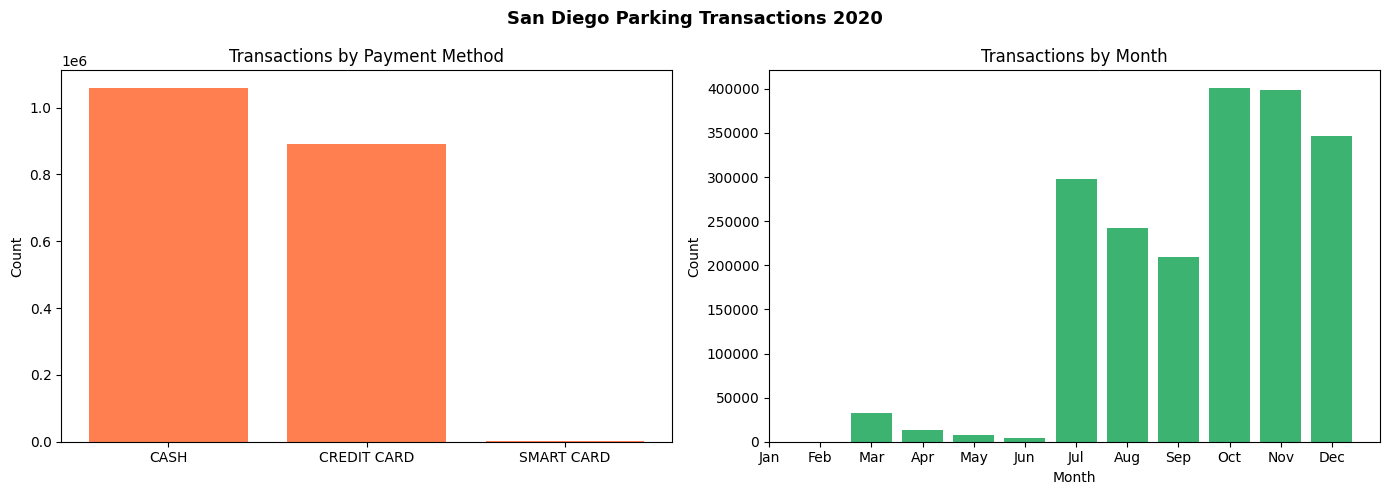

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('San Diego Parking Transactions 2020', fontsize=13, fontweight='bold')

pay_counts = transactions['pay_method'].value_counts()
axes[0].bar(pay_counts.index, pay_counts.values, color='coral')
axes[0].set_title('Transactions by Payment Method')
axes[0].set_ylabel('Count')

monthly = transactions['date_trans_start'].dt.month.value_counts().sort_index()
axes[1].bar(monthly.index, monthly.values, color='mediumseagreen')
axes[1].set_title('Transactions by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

##  Check Join Key

In [26]:
trans_poles  = set(transactions['pole_id'].unique())
loc_poles    = set(locations['pole'].unique())
common_poles = trans_poles.intersection(loc_poles)

print(f'Meters in transactions : {len(trans_poles):,}')
print(f'Meters in locations    : {len(loc_poles):,}')
print(f'Common meters (join)   : {len(common_poles):,}')
print(f'\nJoin key: pole_id (transactions) = pole (locations)')

Meters in transactions : 4,592
Meters in locations    : 4,060
Common meters (join)   : 3,334

Join key: pole_id (transactions) = pole (locations)


#  Data Cleaning

## Step 6: Clean Transactions

In [27]:
# Rename join key to match locations
transactions = transactions.rename(columns={'pole_id': 'pole'})

# Remove duplicates
before = len(transactions)
transactions = transactions.drop_duplicates()
print(f'Duplicates removed : {before - len(transactions):,}')

# Remove rows where expire is before start (invalid)
invalid = transactions[transactions['date_meter_expire'] < transactions['date_trans_start']]
print(f'Invalid rows (expire < start) : {len(invalid):,}')
transactions = transactions[transactions['date_meter_expire'] >= transactions['date_trans_start']]

# Remove zero-duration rows — payment recorded but no time added (data error)
duration_check = (transactions['date_meter_expire'] - transactions['date_trans_start']).dt.total_seconds() / 60
zero_duration = (duration_check == 0).sum()
print(f'Zero-duration rows (payment but 0 mins) : {zero_duration:,}')
transactions = transactions[duration_check > 0]

print(f'\nClean transactions : {len(transactions):,}')

Duplicates removed : 12
Invalid rows (expire < start) : 0
Zero-duration rows (payment but 0 mins) : 44,806

Clean transactions : 1,908,234


##  Clean Locations

In [28]:
# Keep only relevant columns
location_cols = ['pole','zone','area','sub-area','latitude','longitude',
                 'time_limit','days_in_operation','price']
locations = locations[location_cols].copy()

# Remove Spares and Test Zone — not real meters
locations = locations[~locations['zone'].isin(['Spares', 'Test Zone'])]

# Remove rows with invalid coordinates (0,0 dummy entries)
locations = locations[(locations['latitude'].abs() > 1) & (locations['longitude'].abs() > 1)]

# Fill missing values
locations['time_limit']        = locations['time_limit'].fillna('Unknown')
locations['days_in_operation'] = locations['days_in_operation'].fillna('Unknown')
locations['price']             = locations['price'].fillna('Unknown')

print(f'Clean locations : {len(locations):,}')
print(f'Missing values  :\n{locations.isnull().sum()}')

Clean locations : 4,045
Missing values  :
pole                 0
zone                 0
area                 0
sub-area             0
latitude             0
longitude            0
time_limit           0
days_in_operation    0
price                0
dtype: int64


## Step 8: Join Datasets

In [29]:
# Inner join on pole — keeps only meters that exist in both datasets
df = transactions.merge(locations, on='pole', how='inner')

print(f'Merged shape : {df.shape}')
print(f'Columns      : {list(df.columns)}')
df.head()

Merged shape : (1474238, 14)
Columns      : ['pole', 'meter_type', 'date_trans_start', 'date_meter_expire', 'trans_amt', 'pay_method', 'zone', 'area', 'sub-area', 'latitude', 'longitude', 'time_limit', 'days_in_operation', 'price']


,pole,meter_type,date_trans_start,date_meter_expire,trans_amt,pay_method,zone,area,sub-area,latitude,longitude,time_limit,days_in_operation,price
0,IV-424,SS,2020-02-24 11:39:31,2020-02-24 13:39:31,250,CREDIT CARD,Uptown,Bankers Hill,400 IVY ST,32.728334,-117.160658,2 hour,Mon-Sat,$2.50 HR
1,IV-424,SS,2020-02-24 13:24:46,2020-02-24 15:24:46,225,CREDIT CARD,Uptown,Bankers Hill,400 IVY ST,32.728334,-117.160658,2 hour,Mon-Sat,$2.50 HR
2,IV-424,SS,2020-02-24 15:25:52,2020-02-24 17:25:52,250,CREDIT CARD,Uptown,Bankers Hill,400 IVY ST,32.728334,-117.160658,2 hour,Mon-Sat,$2.50 HR
3,WAH-200N,SS,2020-03-16 09:02:46,2020-03-16 11:02:46,250,CREDIT CARD,Downtown,Little Italy,200 WEST ASH ST,32.719903,-117.165766,2 hour,Mon-Sat,$2.50 HR
4,WAH-200N,SS,2020-03-16 09:11:01,2020-03-16 10:11:02,125,CREDIT CARD,Downtown,Little Italy,200 WEST ASH ST,32.719903,-117.165766,2 hour,Mon-Sat,$2.50 HR


#  Feature Engineering

## Time Features

In [31]:
df['hour']         = df['date_trans_start'].dt.hour
df['day_of_week']  = df['date_trans_start'].dt.dayofweek
df['month']        = df['date_trans_start'].dt.month
df['week_of_year'] = df['date_trans_start'].dt.isocalendar().week.astype(int)
df['is_weekend']      = (df['day_of_week'] >= 5).astype(int)
df['is_morning_peak'] = df['hour'].between(8, 10).astype(int)
df['is_midday']       = df['hour'].between(11, 14).astype(int)
df['is_afternoon']    = df['hour'].between(15, 17).astype(int)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin']  = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']  = np.cos(2 * np.pi * df['day_of_week'] / 7)

print('Time features created.')
print(df[['hour','day_of_week','month','is_weekend','is_morning_peak']].head())

Time features created.
   hour  day_of_week  month  is_weekend  is_morning_peak
0    11            0      2           0                0
1    13            0      2           0                0
2    15            0      2           0                0
3     9            0      3           0                1
4     9            0      3           0                1


## Transaction Features

In [32]:
df['duration_mins']     = (df['date_meter_expire'] - df['date_trans_start']).dt.total_seconds() / 60
df['trans_amt_dollars'] = df['trans_amt'] / 100

print('Transaction features created.')
print(df[['duration_mins','trans_amt_dollars']].describe())

Transaction features created.
       duration_mins  trans_amt_dollars
count   1.474238e+06       1.474238e+06
mean    7.819262e+01       1.248536e+00
std     6.568122e+01       1.017022e+00
min     1.666667e-02       0.000000e+00
25%     3.473333e+01       2.500000e-01
50%     6.133333e+01       1.250000e+00
75%     1.200000e+02       2.000000e+00
max     6.598333e+02       9.000000e+00


##  Location Features

In [33]:
df['price_per_hr'] = pd.to_numeric(
    df['price'].str.replace('$','',regex=False).str.replace(' HR','',regex=False).str.strip(),
    errors='coerce').fillna(0)

df['time_limit_mins'] = df['time_limit'].str.extract(r'(\d+)').astype(float).fillna(0)

df['operates_weekend'] = df['days_in_operation'].str.contains(
    'Sat|Sun', case=False, na=False).astype(int)

print('Location features created.')
print(df[['price_per_hr','time_limit_mins','operates_weekend']].head())

Location features created.
   price_per_hr  time_limit_mins  operates_weekend
0           2.5              2.0                 1
1           2.5              2.0                 1
2           2.5              2.0                 1
3           2.5              2.0                 1
4           2.5              2.0                 1


##  Encode Categorical Features

In [34]:
le_zone = LabelEncoder()
le_area = LabelEncoder()
le_pay  = LabelEncoder()

df['zone_enc']       = le_zone.fit_transform(df['zone'].fillna('Unknown'))
df['area_enc']       = le_area.fit_transform(df['area'].fillna('Unknown'))
df['pay_method_enc'] = le_pay.fit_transform(df['pay_method'].fillna('Unknown'))

print('Zone encoding:')
for name, code in zip(le_zone.classes_, range(len(le_zone.classes_))):
    print(f'  {name} -> {code}')

Zone encoding:
  City -> 0
  Downtown -> 1
  Mid-City -> 2
  Uptown -> 3


##  Define Target Variable

In [35]:
# Target: Is Long Stay?
# 1 = Long Stay  — slot occupied for more than 60 minutes (hard to find nearby parking)
# 0 = Short Stay — quick turnover, easier to find a spot
df['is_long_stay'] = (df['duration_mins'] > 60).astype(int)

print('Target variable distribution:')
print(df['is_long_stay'].value_counts())
print(f'\nLong stay rate: {df["is_long_stay"].mean()*100:.1f}%')

Target variable distribution:
is_long_stay
1    786859
0    687379
Name: count, dtype: int64

Long stay rate: 53.4%


## Final Feature List and Train/Test Split

In [36]:
feature_cols = [
    'hour',              # Hour of day
    'day_of_week',       # Day of week (0=Mon)
    'month',             # Month
    'week_of_year',      # Week number
    'is_weekend',        # Weekend flag
    'is_morning_peak',   # 8-10am flag
    'is_midday',         # 11am-2pm flag
    'is_afternoon',      # 3-5pm flag
    'hour_sin',          # Cyclical hour encoding
    'hour_cos',
    'dow_sin',           # Cyclical day encoding
    'dow_cos',
    'trans_amt_dollars', # Amount paid
    'price_per_hr',      # Hourly rate of the meter
    'time_limit_mins',   # Max allowed parking time
    'operates_weekend',  # Does meter operate on weekends
    'zone_enc',          # Zone encoded
    'area_enc',          # Area encoded
    'pay_method_enc'     # Payment method encoded
]

X = df[feature_cols]
y = df['is_long_stay']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Total features  : {len(feature_cols)}')
print(f'Training rows   : {X_train.shape[0]:,}')
print(f'Test rows       : {X_test.shape[0]:,}')

Total features  : 19
Training rows   : 1,179,390
Test rows       : 294,848


#  EXPLORATORY ANALYSIS & MODEL TRAINING

EDA on the preprocessed data, then training both models.

## EDA

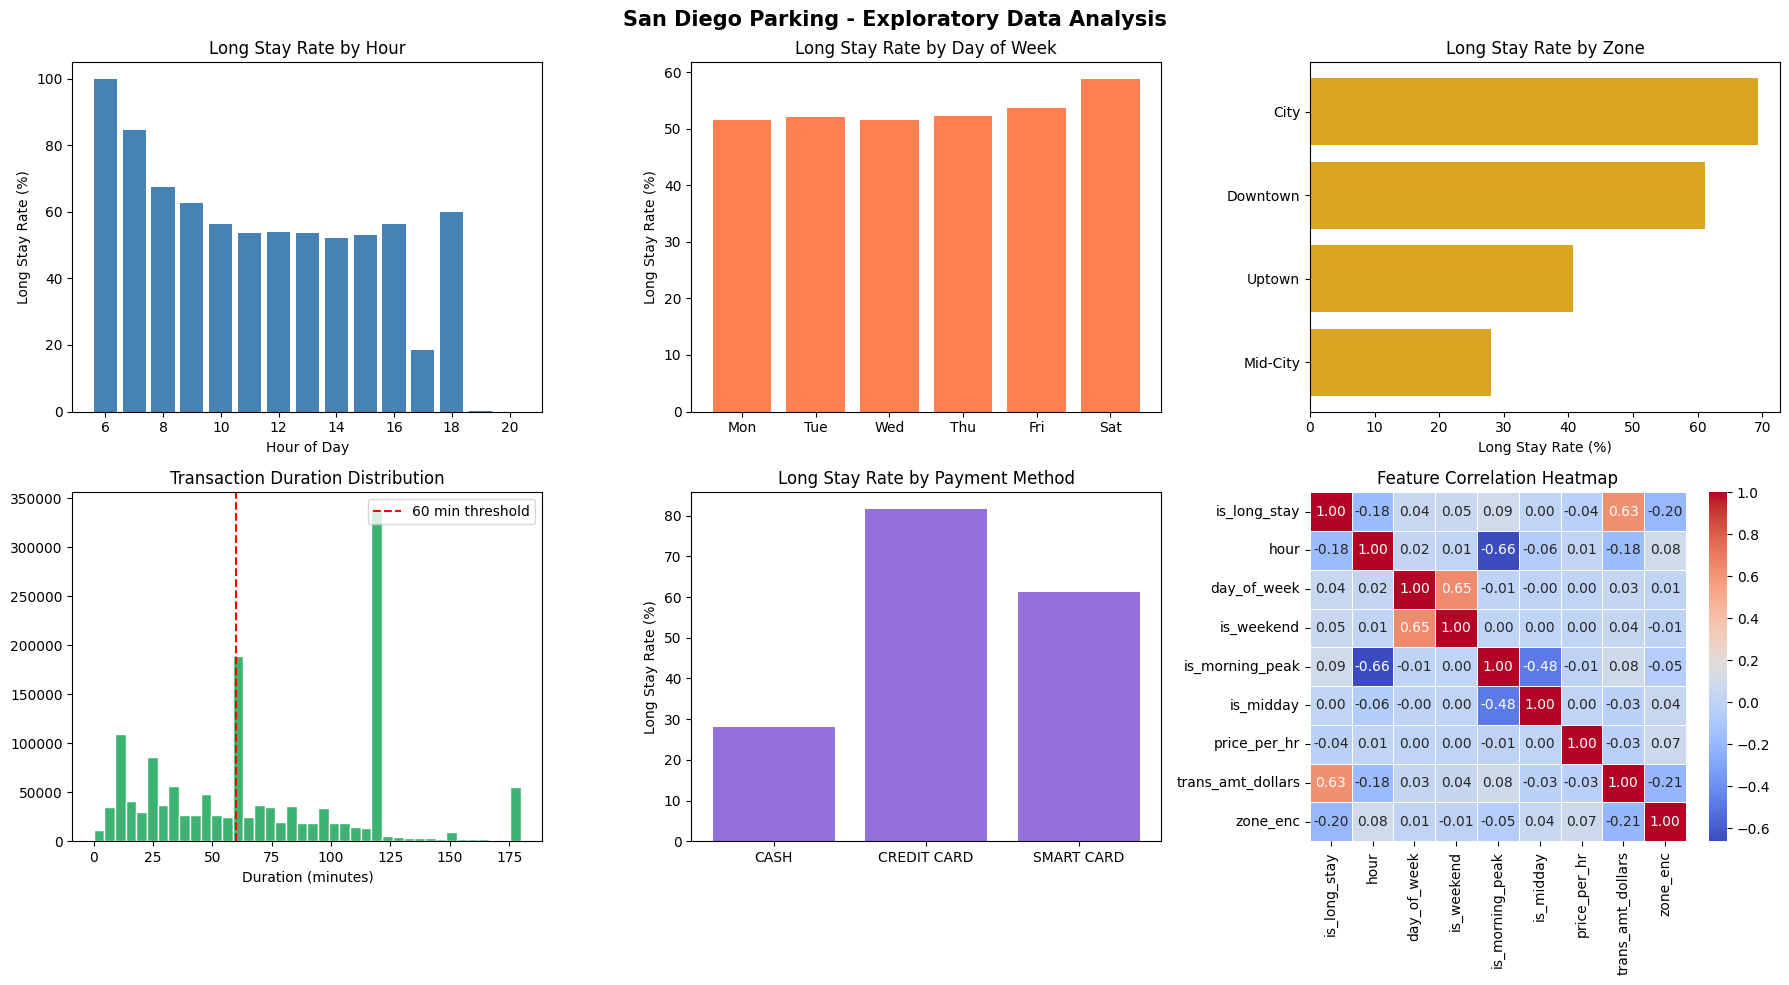

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('San Diego Parking - Exploratory Data Analysis', fontsize=15, fontweight='bold')

# 1. Long stay rate by hour
hourly = df.groupby('hour')['is_long_stay'].mean() * 100
axes[0,0].bar(hourly.index, hourly.values, color='steelblue')
axes[0,0].set_title('Long Stay Rate by Hour')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Long Stay Rate (%)')

# 2. Long stay rate by day of week
# Note: Sunday may have very few or zero valid transactions
# since most San Diego meters do not operate on Sundays
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow = df.groupby('day_of_week')['is_long_stay'].mean() * 100
dow_labels = [day_names[i] for i in dow.index]
axes[0,1].bar(dow_labels, dow.values, color='coral')
axes[0,1].set_title('Long Stay Rate by Day of Week')
axes[0,1].set_ylabel('Long Stay Rate (%)')

# 3. Long stay rate by zone
zone_occ = df.groupby('zone')['is_long_stay'].mean().sort_values() * 100
axes[0,2].barh(zone_occ.index, zone_occ.values, color='goldenrod')
axes[0,2].set_title('Long Stay Rate by Zone')
axes[0,2].set_xlabel('Long Stay Rate (%)')

# 4. Duration distribution
axes[1,0].hist(df['duration_mins'].clip(0, 180), bins=40,
               color='mediumseagreen', edgecolor='white')
axes[1,0].axvline(60, color='red', linestyle='--', label='60 min threshold')
axes[1,0].set_title('Transaction Duration Distribution')
axes[1,0].set_xlabel('Duration (minutes)')
axes[1,0].legend()

# 5. Long stay by payment method
pay_occ = df.groupby('pay_method')['is_long_stay'].mean() * 100
axes[1,1].bar(pay_occ.index, pay_occ.values, color='mediumpurple')
axes[1,1].set_title('Long Stay Rate by Payment Method')
axes[1,1].set_ylabel('Long Stay Rate (%)')

# 6. Correlation heatmap
corr_cols = ['is_long_stay','hour','day_of_week','is_weekend',
             'is_morning_peak','is_midday','price_per_hr',
             'trans_amt_dollars','zone_enc']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', ax=axes[1,2],
            cmap='coolwarm', linewidths=0.5)
axes[1,2].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

## Train Random Forest

In [38]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print('Random Forest training complete.')

Random Forest training complete.


## Train XGBoost

In [39]:
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print('XGBoost training complete.')

XGBoost training complete.


## Train CatBoost

In [40]:
cat_model = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    verbose=0
)

cat_model.fit(X_train, y_train)
cat_pred = cat_model.predict(X_test).flatten()

print('CatBoost training complete.')

CatBoost training complete.


## Train MLP (Deep Learning Baseline)



In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=200,
    random_state=42,
    early_stopping=True
)

mlp_model.fit(X_train_scaled, y_train)
mlp_pred = mlp_model.predict(X_test_scaled)

print('MLP training complete.')

MLP training complete.


In [42]:
models_results = {
    'Random Forest': rf_pred,
    'XGBoost'      : xgb_pred,
    'CatBoost'     : cat_pred,
    'MLP'          : mlp_pred
}

print('Predictions collected for all 4 models.')

Predictions collected for all 4 models.


# POSTPROCESSING

#  Evaluation and Results

## Classification Reports

In [43]:
for name, pred in models_results.items():
    print('=' * 60)
    print(name.upper())
    print('=' * 60)
    print(f'Accuracy : {accuracy_score(y_test, pred):.4f}')
    print(classification_report(y_test, pred,
          target_names=['Short Stay', 'Long Stay']))

RANDOM FOREST
Accuracy : 0.8612
              precision    recall  f1-score   support

  Short Stay       0.80      0.94      0.86    137476
   Long Stay       0.94      0.79      0.86    157372

    accuracy                           0.86    294848
   macro avg       0.87      0.87      0.86    294848
weighted avg       0.87      0.86      0.86    294848

XGBOOST
Accuracy : 0.8640
              precision    recall  f1-score   support

  Short Stay       0.79      0.96      0.87    137476
   Long Stay       0.96      0.78      0.86    157372

    accuracy                           0.86    294848
   macro avg       0.87      0.87      0.86    294848
weighted avg       0.88      0.86      0.86    294848

CATBOOST
Accuracy : 0.8625
              precision    recall  f1-score   support

  Short Stay       0.79      0.96      0.87    137476
   Long Stay       0.95      0.78      0.86    157372

    accuracy                           0.86    294848
   macro avg       0.87      0.87      0.86

##  Confusion Matrices

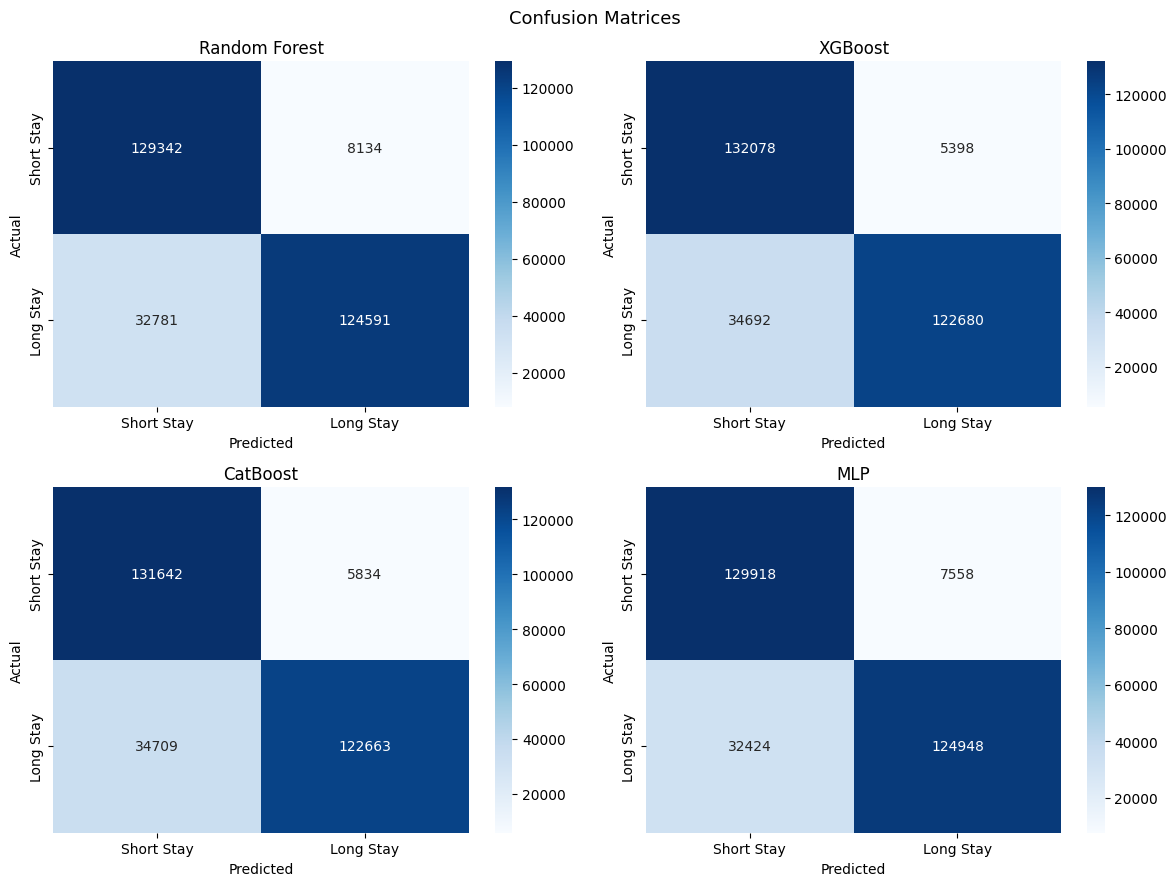

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Confusion Matrices', fontsize=13)
axes = axes.flatten()

for ax, (name, pred) in zip(axes, models_results.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Short Stay','Long Stay'],
                yticklabels=['Short Stay','Long Stay'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Feature Importance

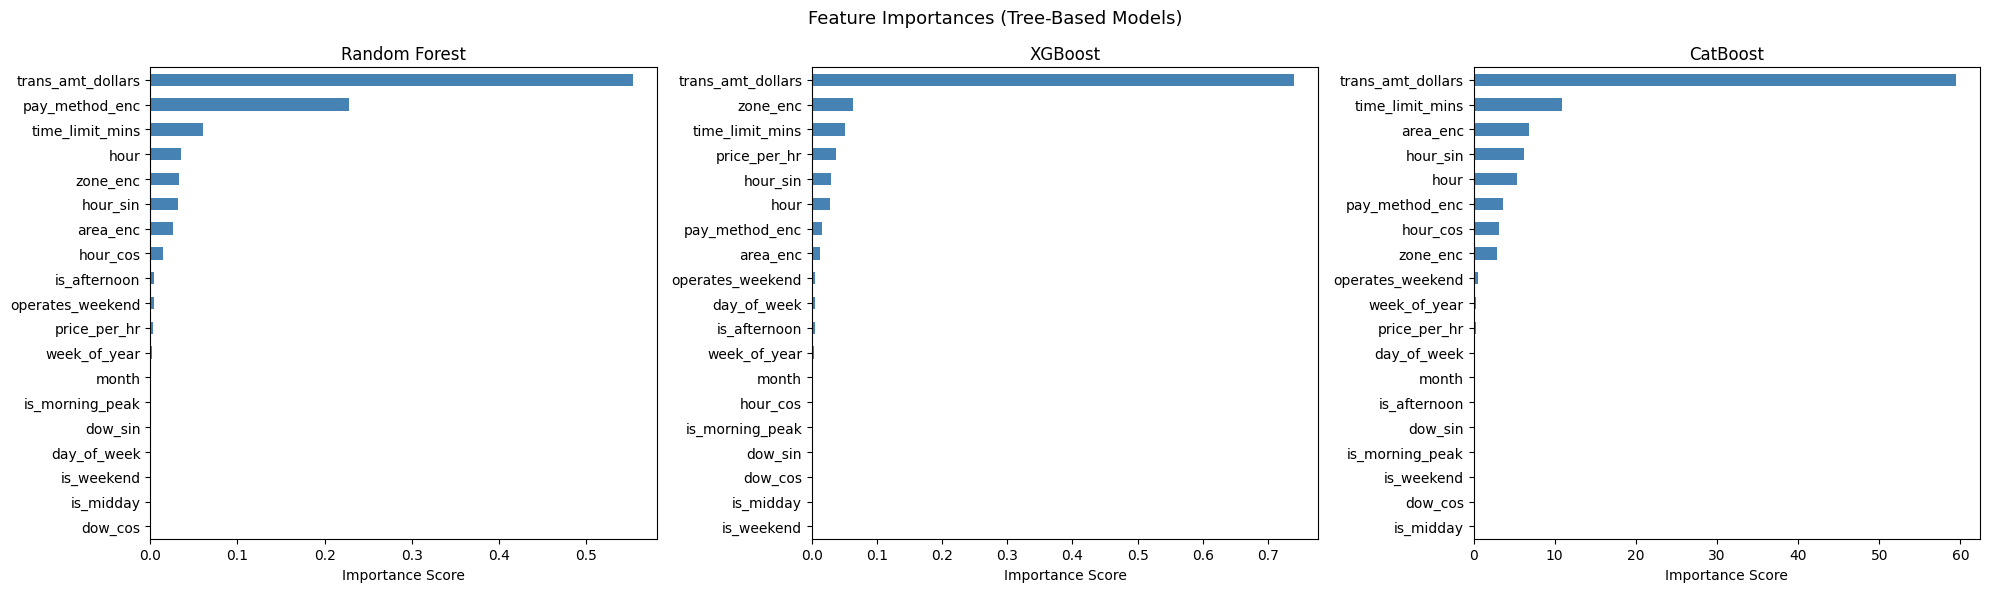

In [45]:
# Feature importance only applies to tree-based models.
# MLP has no feature_importances_ attribute so it is excluded here.
tree_models = {
    'Random Forest': rf_model,
    'XGBoost'      : xgb_model,
    'CatBoost'     : cat_model
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Feature Importances (Tree-Based Models)', fontsize=13)
axes = axes.flatten()

for ax, (title, model) in zip(axes, tree_models.items()):
    imp = pd.Series(model.feature_importances_, index=feature_cols)
    imp.sort_values(ascending=True).plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

##  Model Comparison Table

In [47]:
results = pd.DataFrame({
    'Model'    : list(models_results.keys()),
    'Accuracy' : [round(accuracy_score(y_test, p), 4) for p in models_results.values()],
    'Precision': [round(precision_score(y_test, p), 4) for p in models_results.values()],
    'Recall'   : [round(recall_score(y_test, p), 4) for p in models_results.values()],
    'F1 Score' : [round(f1_score(y_test, p), 4) for p in models_results.values()]
})

print('=' * 60)
print('       FINAL MODEL COMPARISON')
print('=' * 60)
print(results.to_string(index=False))
print('=' * 60)
best = results.loc[results['F1 Score'].idxmax(), 'Model']
print(f'\nBest Model: {best}')

       FINAL MODEL COMPARISON
        Model  Accuracy  Precision  Recall  F1 Score
Random Forest    0.8612     0.9387  0.7917    0.8590
      XGBoost    0.8640     0.9579  0.7796    0.8596
     CatBoost    0.8625     0.9546  0.7794    0.8582
          MLP    0.8644     0.9430  0.7940    0.8621

Best Model: MLP


# Ablation Study: Without `trans_amt_dollars`


In [48]:
feature_cols_no_amt = [c for c in feature_cols if c != 'trans_amt_dollars']

X2 = df[feature_cols_no_amt]
y2 = df['is_long_stay']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

print(f'Features without trans_amt_dollars : {len(feature_cols_no_amt)}')
print(f'Training rows : {X2_train.shape[0]:,}')
print(f'Test rows     : {X2_test.shape[0]:,}')

Features without trans_amt_dollars : 18
Training rows : 1,179,390
Test rows     : 294,848


## Retrain All 4 Models Without `trans_amt_dollars`

In [49]:
scale2 = (y2_train == 0).sum() / (y2_train == 1).sum()

rf_model2 = RandomForestClassifier(
    n_estimators=100, max_depth=12, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_model2.fit(X2_train, y2_train)
rf_pred2 = rf_model2.predict(X2_test)

xgb_model2 = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale2, random_state=42,
    eval_metric='logloss', verbosity=0
)
xgb_model2.fit(X2_train, y2_train)
xgb_pred2 = xgb_model2.predict(X2_test)

cat_model2 = CatBoostClassifier(
    iterations=100, depth=6, learning_rate=0.1,
    scale_pos_weight=scale2, random_state=42, verbose=0
)
cat_model2.fit(X2_train, y2_train)
cat_pred2 = cat_model2.predict(X2_test).flatten()

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled  = scaler2.transform(X2_test)

mlp_model2 = MLPClassifier(
    hidden_layer_sizes=(64, 32), activation='relu',
    max_iter=200, random_state=42, early_stopping=True
)
mlp_model2.fit(X2_train_scaled, y2_train)
mlp_pred2 = mlp_model2.predict(X2_test_scaled)

models_results2 = {
    'Random Forest': rf_pred2,
    'XGBoost'      : xgb_pred2,
    'CatBoost'     : cat_pred2,
    'MLP'          : mlp_pred2
}

print('All 4 models retrained without trans_amt_dollars.')

All 4 models retrained without trans_amt_dollars.


## Side-by-Side Comparison: With vs Without `trans_amt_dollars`

In [50]:
results2 = pd.DataFrame({
    'Model'    : list(models_results2.keys()),
    'Accuracy' : [round(accuracy_score(y2_test, p), 4) for p in models_results2.values()],
    'Precision': [round(precision_score(y2_test, p), 4) for p in models_results2.values()],
    'Recall'   : [round(recall_score(y2_test, p), 4) for p in models_results2.values()],
    'F1 Score' : [round(f1_score(y2_test, p), 4) for p in models_results2.values()]
})

comparison = results[['Model','Accuracy','F1 Score']].merge(
    results2[['Model','Accuracy','F1 Score']],
    on='Model', suffixes=(' (with amount)', ' (without amount)')
)

print('=' * 70)
print('   SIDE-BY-SIDE: WITH vs WITHOUT trans_amt_dollars')
print('=' * 70)
print(comparison.to_string(index=False))
print('=' * 70)

   SIDE-BY-SIDE: WITH vs WITHOUT trans_amt_dollars
        Model  Accuracy (with amount)  F1 Score (with amount)  Accuracy (without amount)  F1 Score (without amount)
Random Forest                  0.8612                  0.8590                     0.8074                     0.8043
      XGBoost                  0.8640                  0.8596                     0.8084                     0.8065
     CatBoost                  0.8625                  0.8582                     0.8067                     0.8039
          MLP                  0.8644                  0.8621                     0.8093                     0.8097


##  Prediction Function

In [51]:
def predict_stay(hour, day_of_week, month, week_of_year,
                  trans_amt_dollars, price_per_hr, time_limit_mins,
                  operates_weekend, zone_name, area_name, pay_method_name):
    """
    Predict whether a parking slot will be a Long Stay (>60 mins)
    or Short Stay (<=60 mins), using all trained models.
    """
    is_weekend      = 1 if day_of_week >= 5 else 0
    is_morning_peak = 1 if 8 <= hour <= 10 else 0
    is_midday       = 1 if 11 <= hour <= 14 else 0
    is_afternoon    = 1 if 15 <= hour <= 17 else 0
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)
    dow_sin  = np.sin(2 * np.pi * day_of_week / 7)
    dow_cos  = np.cos(2 * np.pi * day_of_week / 7)

    zone_enc       = le_zone.transform([zone_name])[0]
    area_enc       = le_area.transform([area_name])[0]
    pay_method_enc = le_pay.transform([pay_method_name])[0]

    input_data = pd.DataFrame([{
        'hour': hour, 'day_of_week': day_of_week, 'month': month,
        'week_of_year': week_of_year, 'is_weekend': is_weekend,
        'is_morning_peak': is_morning_peak, 'is_midday': is_midday,
        'is_afternoon': is_afternoon, 'hour_sin': hour_sin, 'hour_cos': hour_cos,
        'dow_sin': dow_sin, 'dow_cos': dow_cos,
        'trans_amt_dollars': trans_amt_dollars, 'price_per_hr': price_per_hr,
        'time_limit_mins': time_limit_mins, 'operates_weekend': operates_weekend,
        'zone_enc': zone_enc, 'area_enc': area_enc, 'pay_method_enc': pay_method_enc
    }])[feature_cols]

    input_scaled = scaler.transform(input_data)

    for name, model in [('Random Forest', rf_model), ('XGBoost', xgb_model),
                         ('CatBoost', cat_model)]:
        p    = model.predict(input_data)[0]
        prob = model.predict_proba(input_data)[0][1]
        print(f'{name:<15} -> {"Long Stay" if p==1 else "Short Stay"} (probability: {prob:.2f})')

    mlp_p    = mlp_model.predict(input_scaled)[0]
    mlp_prob = mlp_model.predict_proba(input_scaled)[0][1]
    print(f'{"MLP":<15} -> {"Long Stay" if mlp_p==1 else "Short Stay"} (probability: {mlp_prob:.2f})')

print('Prediction function ready.')

Prediction function ready.


In [52]:
# Example: Predict for a weekday morning, downtown zone, credit card payment
predict_stay(
    hour=9, day_of_week=1, month=6, week_of_year=24,
    trans_amt_dollars=2.50, price_per_hr=2.50, time_limit_mins=120,
    operates_weekend=1,
    zone_name=df['zone'].iloc[0],
    area_name=df['area'].iloc[0],
    pay_method_name='CREDIT CARD'
)

Random Forest   -> Long Stay (probability: 0.95)
XGBoost         -> Long Stay (probability: 1.00)
CatBoost        -> Long Stay (probability: 0.99)
MLP             -> Short Stay (probability: 0.00)
